# Trabajo Practico Integrador — Entrega 3
## Ciencia de Datos 2026 | UTN FRC | 5K4 | Grupo 15

---

### Descripcion

Valida la **Hipotesis H1** probando multiples familias de algoritmos de Machine Learning y comparando el mejor de cada una.

> **H1:** *"Existe una correlacion positiva y cuantificable entre la frecuencia cardiaca media del sujeto y el nivel de intensidad de la actividad fisica clasificada (baja, moderada y vigorosa)."*

**Estructura:**
| Sec | Contenido | Target |
|-----|-----------|--------|
| 0 | Setup | — |
| 1 | Exploracion + Division por sujetos | — |
| 2 | Metodos Lineales (LinReg, Lasso, LogReg) | `nivel_intensidad` (H1) |
| 3 | Arboles de Decision (DT, RF, ExtraTrees) | `actividad_id` (12 clases) |
| 4 | Gradient Boosting (HistGradientBoosting) | `actividad_id` |
| 5 | Otros Clasificadores (SVM, K-NN, NaiveBayes) | `actividad_id` |
| 6 | Comparacion Global + FP/FN | — |
| 7 | Demostracion en Vivo | — |
| 8 | Conclusiones | — |

**Division de datos:** sujetos 102, 106, 108 para prueba (~35%). Resto para entrenamiento.

---

| Rol | Nombre | Legajo |
|-----|--------|--------|
| Product Owner | Franco Recalde | 94661 |
| Scrum Master | Emilio Sadir | 96622 |
| dev | Rodriguez, Joaquin Ignacio | 85406 |
| dev | Noto, Claudia Carina | 95215 |
| dev | Monteros, Leandro Ignacio | 90258 |
| dev | Ferraro, Ayelen | 99149 |
| dev | Chiaro, Tiziano | 90043 |
| dev | Bailey, Julian Eduardo | 96032 |

---
# Seccion 0 — Setup

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier)
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, r2_score,
    mean_squared_error, mean_absolute_error
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print('Librerias cargadas.')

Librerias cargadas.


In [188]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/TP_CD')
else:
    BASE_PATH = Path('..').resolve()

DATA_PATH    = BASE_PATH / 'data' / 'processed' / 'pamap2_limpio.csv'
FIGURES_PATH = BASE_PATH / 'reports' / 'entrega_3' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')

Entorno: Local


In [189]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas | Nulos: {df.isnull().sum().sum()}')
total = len(df)
filas_x_sujeto = df.groupby('sujeto_id').size().rename('filas')
display(pd.concat([filas_x_sujeto, (filas_x_sujeto/total*100).round(1).rename('pct%')], axis=1))

Shape: 109,812 filas x 43 columnas | Nulos: 0


,filas,pct%
sujeto_id,,
101,14057,12.8000
102,13039,11.9000
103,10005,9.1000
104,13967,12.7000
105,15586,14.2000
106,15009,13.7000
107,17346,15.8000
108,10390,9.5000
109,413,0.4000


### Paso 0.3 — Constantes, feature engineering y funciones auxiliares

In [190]:
# --- Nombres de actividades en espanol ---
ACTIVIDAD_MAP = {
    1: 'acostado',        2: 'sentado',          3: 'de pie',
    4: 'caminata',        5: 'corriendo',         6: 'ciclismo',
    7: 'marcha nordica',  12: 'subir escaleras', 13: 'bajar escaleras',
    16: 'aspirar',        17: 'planchar',          24: 'saltar soga'
}

# Ciclismo = vigoroso (alta demanda cardiovascular)
INTENSIDAD_MAP = {
    1: 0, 2: 0, 3: 0,       # baja:     acostado, sentado, de pie
    4: 1, 16: 1, 17: 1,     # moderada: caminata, aspirar, planchar
    5: 2, 6: 2, 7: 2,       # vigorosa: corriendo, ciclismo, marcha nordica
    12: 2, 13: 2, 24: 2,    # vigorosa: subir/bajar escaleras, saltar soga
}
INTENSIDAD_NOMBRES = {0: 'baja', 1: 'moderada', 2: 'vigorosa'}
INTENSIDAD_COLORES = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
INTENSIDAD_ORDEN   = ['baja', 'moderada', 'vigorosa']

df['nivel_intensidad'] = df['actividad_id'].map(INTENSIDAD_MAP)

# Magnitudes invariantes a la orientacion del sensor
for parte in ['mano', 'pecho', 'tobillo']:
    for sensor in ['acel1', 'acel2']:
        cols = [f'{parte}_{sensor}_{ax}' for ax in ['x', 'y', 'z']]
        if all(c in df.columns for c in cols):
            df[f'{parte}_{sensor}_mag'] = np.sqrt((df[cols] ** 2).sum(axis=1))
    cols_g = [f'{parte}_giro_{ax}' for ax in ['x', 'y', 'z']]
    if all(c in df.columns for c in cols_g):
        df[f'{parte}_giro_mag'] = np.sqrt((df[cols_g] ** 2).sum(axis=1))

SENSOR_COLS = [c for c in df.columns
               if c not in ['tiempo', 'actividad_id', 'sujeto_id', 'nivel_intensidad']]
mag_cols = [c for c in SENSOR_COLS if c.endswith('_mag')]

print(f'SENSOR_COLS: {len(SENSOR_COLS)} features ({len(mag_cols)} magnitudes)')
print()
for k in [0, 1, 2]:
    n    = (df['nivel_intensidad'] == k).sum()
    acts = [ACTIVIDAD_MAP[a] for a, v in INTENSIDAD_MAP.items() if v == k]
    print(f'  {INTENSIDAD_NOMBRES[k]:10s} ({k}): {n:,} filas  <- {acts}')

# Dict global donde cada seccion almacena sus resultados de clasificacion
todos_clasificadores = {}


def plot_cm(y_true, y_pred, labels, label_names, title, filename=None, figsize=(12, 10)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.4, cbar=False)
    ax.set_xlabel('Predicho', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    if filename:
        plt.savefig(FIGURES_PATH / filename, dpi=100, bbox_inches='tight')
    plt.show()


def analizar_fp_fn(nombre_modelo, y_pred):
    """Genera tabla y grafico de FP/FN. Usa globals: y_test_act, h_labels, ACTIVIDAD_MAP."""
    y_true = y_test_act.values
    rows = []
    for act_id in h_labels:
        mask_r = (y_true == act_id);  mask_p = (y_pred == act_id)
        tp = int(np.sum(mask_r & mask_p));    fp = int(np.sum(~mask_r & mask_p))
        fn = int(np.sum(mask_r & ~mask_p));   tn = int(np.sum(~mask_r & ~mask_p))
        prec   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        rows.append({'Actividad': ACTIVIDAD_MAP.get(act_id, str(act_id)),
                     'Total real': int(mask_r.sum()),
                     'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                     'Precision': round(prec, 3), 'Recall': round(recall, 3)})
    df_fpfn = pd.DataFrame(rows).set_index('Actividad')
    display(df_fpfn.style
            .format({'Precision': '{:.3f}', 'Recall': '{:.3f}'})
            .background_gradient(subset=['FP', 'FN'], cmap='Reds')
            .set_caption(f'FP y FN — {nombre_modelo}'))

    fig, ax = plt.subplots(figsize=(13, 6))
    x, w = np.arange(len(df_fpfn)), 0.35
    b1 = ax.bar(x - w/2, df_fpfn['FP'], w, label='Falsos Positivos', color='#FF7043', alpha=0.87)
    b2 = ax.bar(x + w/2, df_fpfn['FN'], w, label='Falsos Negativos', color='#1565C0', alpha=0.87)
    ax.set_xticks(x);  ax.set_xticklabels(df_fpfn.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Cantidad de registros')
    ax.set_title(f'Falsos Positivos y Negativos — {nombre_modelo}')
    ax.legend(fontsize=10)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                    str(int(h)), ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'fp_fn_mejor_global.png', dpi=100, bbox_inches='tight')
    plt.show()
    return df_fpfn


def evaluar_clasificador(nombre, modelo, y_pred):
    """Calcula metricas de clasificacion y almacena en todos_clasificadores."""
    y_pred_enc = le.transform(y_pred)
    acc_train  = accuracy_score(y_train_act, modelo.predict(X_train))
    acc_test   = accuracy_score(y_test_act,  y_pred)
    f1_val     = f1_score(y_test_act, y_pred, average='macro', zero_division=0)
    r2_val     = r2_score(y_test_enc, y_pred_enc)
    todos_clasificadores[nombre] = {
        'modelo': modelo, 'y_pred': y_pred,
        'acc_train': acc_train, 'acc_test': acc_test,
        'f1_macro': f1_val, 'R2': r2_val
    }
    print(f'  Exactitud entrena: {acc_train:.4f}')
    print(f'  Exactitud prueba:  {acc_test:.4f}')
    print(f'  F1 macro:          {f1_val:.4f}')
    print(f'  R2 (etiq. 0-11):   {r2_val:.4f}   {"OK >= 0.6" if r2_val >= 0.6 else "bajo"}')
    return todos_clasificadores[nombre]

SENSOR_COLS: 49 features (9 magnitudes)

  baja       (0): 27,527 filas  <- ['acostado', 'sentado', 'de pie']
  moderada   (1): 38,902 filas  <- ['caminata', 'aspirar', 'planchar']
  vigorosa   (2): 43,383 filas  <- ['corriendo', 'ciclismo', 'marcha nordica', 'subir escaleras', 'bajar escaleras', 'saltar soga']


---
# Seccion 1 — Exploracion y Division por Sujetos

**Mapeo de intensidad:**

| Nivel | Cod | Actividades |
|-------|-----|-------------|
| Baja | 0 | acostado, sentado, de pie |
| Moderada | 1 | caminata, aspirar, planchar |
| Vigorosa | 2 | corriendo, ciclismo, marcha nordica, subir/bajar escaleras, saltar soga |

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13164\1554710009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='nivel_nombre', y='frecuencia_cardiaca',


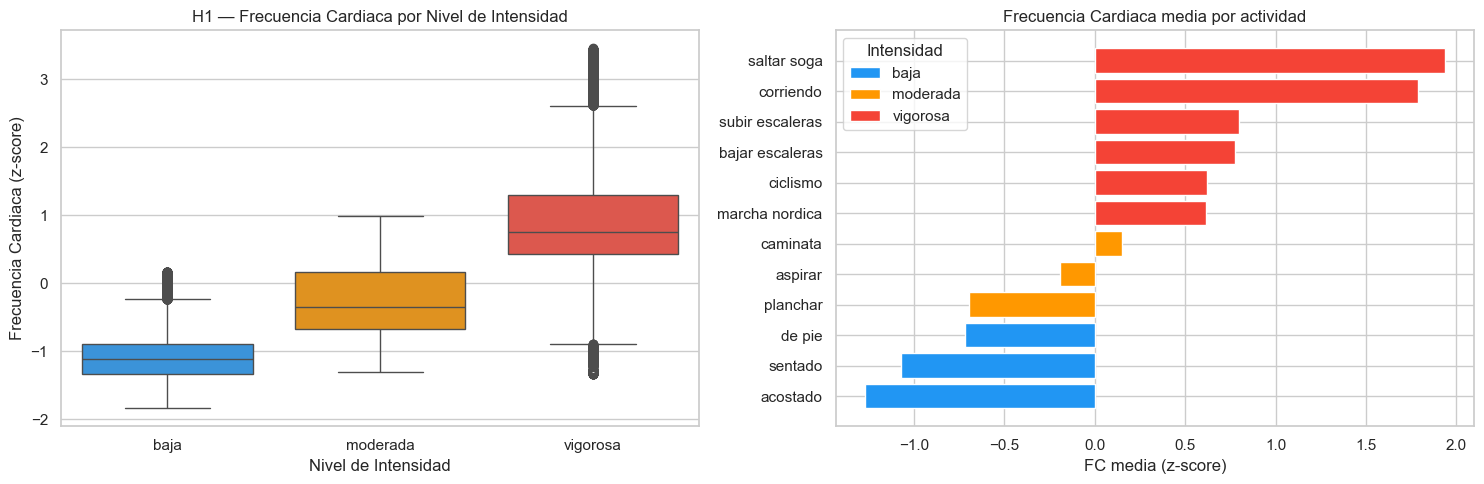

,count,mean,std,min,25%,50%,75%,max
nivel_intensidad,,,,,,,,
baja,27527.0000,-1.0724,0.3948,-1.8397,-1.3289,-1.1130,-0.8911,0.1669
moderada,38902.0000,-0.2578,0.4973,-1.3107,-0.6722,-0.3438,0.1669,0.9795
vigorosa,43383.0000,0.9116,0.7683,-1.3289,0.4223,0.7507,1.2979,3.4505


In [191]:
df_plot = df.copy()
df_plot['nivel_nombre'] = df_plot['nivel_intensidad'].map(INTENSIDAD_NOMBRES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df_plot, x='nivel_nombre', y='frecuencia_cardiaca',
            order=INTENSIDAD_ORDEN,
            palette=[INTENSIDAD_COLORES[k] for k in [0, 1, 2]], ax=axes[0])
axes[0].set_title('H1 — Frecuencia Cardiaca por Nivel de Intensidad', fontsize=12)
axes[0].set_xlabel('Nivel de Intensidad')
axes[0].set_ylabel('Frecuencia Cardiaca (z-score)')

fc_media   = df.groupby('actividad_id')['frecuencia_cardiaca'].mean().sort_values()
bar_colors = [INTENSIDAD_COLORES[INTENSIDAD_MAP[a]] for a in fc_media.index]
act_names  = [ACTIVIDAD_MAP.get(a, str(a)) for a in fc_media.index]
axes[1].barh(act_names, fc_media.values, color=bar_colors)
axes[1].set_title('Frecuencia Cardiaca media por actividad', fontsize=12)
axes[1].set_xlabel('FC media (z-score)')
axes[1].legend(handles=[mpatches.Patch(facecolor=INTENSIDAD_COLORES[k],
               label=INTENSIDAD_NOMBRES[k]) for k in [0, 1, 2]], title='Intensidad')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'h1_boxplot_intensidad.png', dpi=100, bbox_inches='tight')
plt.show()
display(df.groupby('nivel_intensidad')['frecuencia_cardiaca'].describe().rename(index=INTENSIDAD_NOMBRES))

### 1.2 — Division por Sujetos

Los **sujetos 102, 106, 108** conforman el conjunto de prueba (~35.0%, 38.438 filas).
El resto —incluido el sujeto 109— forma el conjunto de entrenamiento.

> **Por que no split aleatorio?** Si filas del mismo sujeto estan en train y test, el modelo memoriza
> los patrones de movimiento especificos de esa persona (cadencia, FC basal) y obtiene una performance
> artificialmente alta. Con split por sujetos se mide la generalizacion real a personas nuevas.

| Conjunto | Sujetos | Filas | % |
|----------|---------|-------|---|
| Entrenamiento | 101, 103, 104, 105, 107, 109 | ~71.374 | ~65.0% |
| Prueba | 102, 106, 108 | ~38.438 | ~35.0% |

In [192]:
SUJETOS_PRUEBA = [102, 106, 108]   # ~35% del dataset
# Sujeto 109 incluido en entrenamiento (solo 413 filas pero datos validos)

df_train = df[~df['sujeto_id'].isin(SUJETOS_PRUEBA)].copy()
df_test  = df[df['sujeto_id'].isin(SUJETOS_PRUEBA)].copy()

X_train = df_train[SENSOR_COLS]
X_test  = df_test[SENSOR_COLS]
y_train_act = df_train['actividad_id']
y_test_act  = df_test['actividad_id']
y_train_int = df_train['nivel_intensidad']
y_test_int  = df_test['nivel_intensidad']

# LabelEncoder: IDs [1,2,3,4,5,6,7,12,13,16,17,24] -> [0..11]
# Necesario para R2 en clasificacion: evita que la diferencia entre ID 1 y ID 24
# infle artificialmente los residuos y hunda el R2.
h_labels      = sorted(y_test_act.unique())
h_label_names = [ACTIVIDAD_MAP.get(a, str(a)) for a in h_labels]
le = LabelEncoder().fit(h_labels)

print(f'Entrenamiento: {len(X_train):,} filas ({len(X_train)/len(df)*100:.1f}%) sujetos: {sorted(df_train["sujeto_id"].unique())}')
print(f'Prueba:        {len(X_test):,}  filas ({len(X_test)/len(df)*100:.1f}%) sujetos: {SUJETOS_PRUEBA}')
print(f'Features:      {X_train.shape[1]} (incluye {len(mag_cols)} magnitudes)')

Entrenamiento: 71,374 filas (65.0%) sujetos: [np.int64(101), np.int64(103), np.int64(104), np.int64(105), np.int64(107), np.int64(109)]
Prueba:        38,438  filas (35.0%) sujetos: [102, 106, 108]
Features:      49 (incluye 9 magnitudes)


### Por que baja la precision con split por sujetos?

Con split aleatorio (65/35), el mismo sujeto aparece en train y test. El modelo **memoriza** los patrones
individuales de cada persona y puede superar el 90%. Con split por sujetos debe **generalizar** a personas
nuevas: la caida tipica en PAMAP2 es del ~90% → ~70-85%. Esa es la performance **real** del sistema.

**Estrategias para mejorar la generalizacion (ya aplicadas):**
1. **Magnitudes de aceleracion** — invariantes a la orientacion del sensor, mas consistentes entre sujetos
2. **Extra Trees** — cortes de split aleatorios generan mayor diversidad entre arboles → menos overfitting

**Nota sobre R2 en clasificacion:** los IDs de actividad son no-consecutivos (1,2,3,4,5,6,7,**12,13,16,17,24**).
Si el modelo predice 7 en lugar de 24, el residuo es 17 — mucho mayor que si los IDs fueran [0..11].
Esto hunde artificialmente el R2. Se usa `LabelEncoder` para mapear a [0..11] antes de calcular R2.

---
# Seccion 2 — Metodos Lineales

**Target:** `nivel_intensidad` (0=baja, 1=moderada, 2=vigorosa) — valida **H1**.

| Modelo | Descripcion |
|--------|-------------|
| **Regresion Lineal** | Minimiza suma de errores cuadrados. Predice valor continuo en [−∞,+∞], se redondea a {0,1,2}. |
| **Lasso (L1)** | Igual que RegLin pero penaliza coef: anula coeficientes redundantes → seleccion automatica de variables. |
| **Reg. Logistica** | Predice probabilidades por clase P(baja), P(moderada), P(vigorosa). Se usa la esperanza: 0*P(0)+1*P(1)+2*P(2) como prediccion continua comparable con los otros modelos. Es el puente entre regresion y clasificacion. |

### Glosario de metricas

| Metrica | Que mide |
|---------|----------|
| **R2** | Proporcion de variabilidad del target explicada. R2=1 perfecto; R2=0 = predecir la media. **Requisito: R2 >= 0.6** |
| **RMSE** | Error promedio en unidades del target. Penaliza errores grandes. |
| **MAE** | Promedio de errores absolutos. Mas robusto a extremos que RMSE. |
| **r de Pearson** | Correlacion lineal (-1 a +1). r>0: a mas FC, mas intensidad. Clave para H1. |
| **p-valor** | Probabilidad de la correlacion por azar. p<0.05 = estadisticamente significativa. |

In [193]:
modelos_reg = {
    'Regresion Lineal':  LinearRegression(),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01, max_iter=5000),
    'Reg. Logistica':    LogisticRegression(multi_class='multinomial',
                                            solver='lbfgs', max_iter=1000),
}

resultados_reg = {}
idx_fc = list(SENSOR_COLS).index('frecuencia_cardiaca')

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train, y_train_int)

    # Prediccion continua (para metricas de regresion):
    # - LinReg / Lasso: valor continuo directo
    # - LogReg: esperanza = sum(k * P(class k | x)) en [0, 2]
    if hasattr(modelo, 'predict_proba'):
        proba      = modelo.predict_proba(X_test)
        y_pred_raw = proba @ np.array([0.0, 1.0, 2.0])
    else:
        y_pred_raw = modelo.predict(X_test)

    y_pred_disc = np.clip(np.round(y_pred_raw), 0, 2).astype(int)
    r2_val   = r2_score(y_test_int, y_pred_raw)
    rmse_val = np.sqrt(mean_squared_error(y_test_int, y_pred_raw))
    mae_val  = mean_absolute_error(y_test_int, y_pred_raw)
    r_val, p_val = stats.pearsonr(y_test_int, y_pred_raw)

    # Efecto de FC sobre intensidad
    if modelo.coef_.ndim == 1:
        # LinReg / Lasso: coef_ shape = (n_features,)
        coef_fc = modelo.coef_[idx_fc]
        n_zero  = int(np.sum(np.abs(modelo.coef_) < 1e-8))
    else:
        # LogReg: coef_ shape = (n_classes, n_features)
        # Efecto neto = diferencia entre clase vigorosa (2) y baja (0)
        coef_fc = float(modelo.coef_[2, idx_fc] - modelo.coef_[0, idx_fc])
        n_zero  = 0

    resultados_reg[nombre] = {
        'modelo': modelo, 'y_pred_raw': y_pred_raw, 'y_pred_disc': y_pred_disc,
        'R2': r2_val, 'RMSE': rmse_val, 'MAE': mae_val,
        'r_Pearson': r_val, 'p_valor': p_val, 'coef_fc': coef_fc, 'n_zero': n_zero,
        'es_lineal_simple': modelo.coef_.ndim == 1
    }

    print(f'--- {nombre} ---')
    print(f'  R2:           {r2_val:.4f}   {"OK >= 0.6" if r2_val >= 0.6 else "BAJO < 0.6"}')
    print(f'  RMSE:         {rmse_val:.4f}')
    print(f'  MAE:          {mae_val:.4f}')
    print(f'  r de Pearson: {r_val:.4f}')
    print(f'  p-valor:      {p_val:.2e}   {"significativo" if p_val < 0.05 else "NO significativo"}')
    if modelo.coef_.ndim == 1:
        print(f'  Coef. FC:     {coef_fc:+.4f}   {"H1 OK" if coef_fc > 0 else "negativo"}')
        if n_zero: print(f'  Coefs = 0:    {n_zero}/{len(SENSOR_COLS)} (Lasso)')
    else:
        print(f'  Efecto FC:    {coef_fc:+.4f}   (LogReg: log-odds vigorosa - baja. {"H1 OK" if coef_fc > 0 else "negativo"})')
    print()

mejor_reg_nombre = max(resultados_reg, key=lambda n: resultados_reg[n]['R2'])
print(f'>>> Mejor regresion: {mejor_reg_nombre}  (R2 = {resultados_reg[mejor_reg_nombre]["R2"]:.4f})')

--- Regresion Lineal ---
  R2:           0.6111   OK >= 0.6
  RMSE:         0.4553
  MAE:          0.3761
  r de Pearson: 0.7925
  p-valor:      0.00e+00   significativo
  Coef. FC:     +0.4789   H1 OK

--- Lasso (alpha=0.01) ---
  R2:           0.6095   OK >= 0.6
  RMSE:         0.4562
  MAE:          0.3774
  r de Pearson: 0.7883
  p-valor:      0.00e+00   significativo
  Coef. FC:     +0.4785   H1 OK
  Coefs = 0:    25/49 (Lasso)



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Reg. Logistica ---
  R2:           0.7231   OK >= 0.6
  RMSE:         0.3842
  MAE:          0.2043
  r de Pearson: 0.8519
  p-valor:      0.00e+00   significativo
  Efecto FC:    +9.5382   (LogReg: log-odds vigorosa - baja. H1 OK)

>>> Mejor regresion: Reg. Logistica  (R2 = 0.7231)


### 2.1 — Comparacion de metricas y coeficientes (Reg. Lineal vs Lasso vs Reg. Logistica)

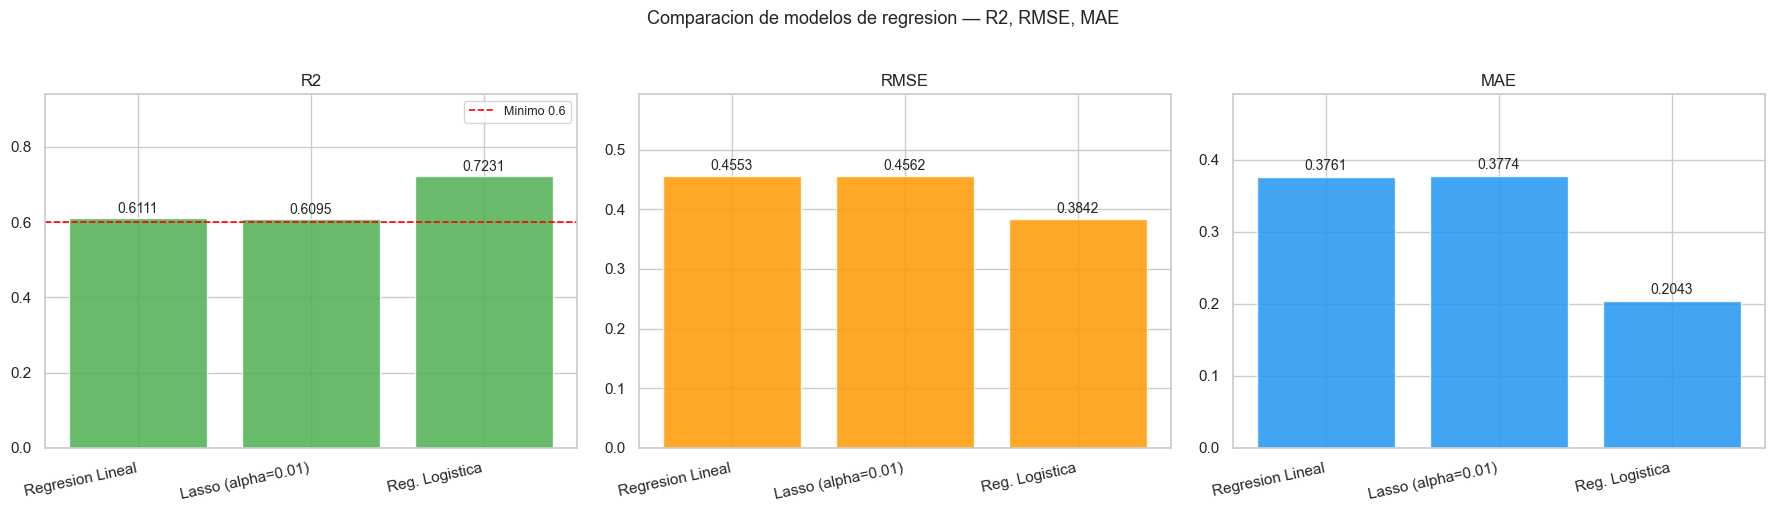

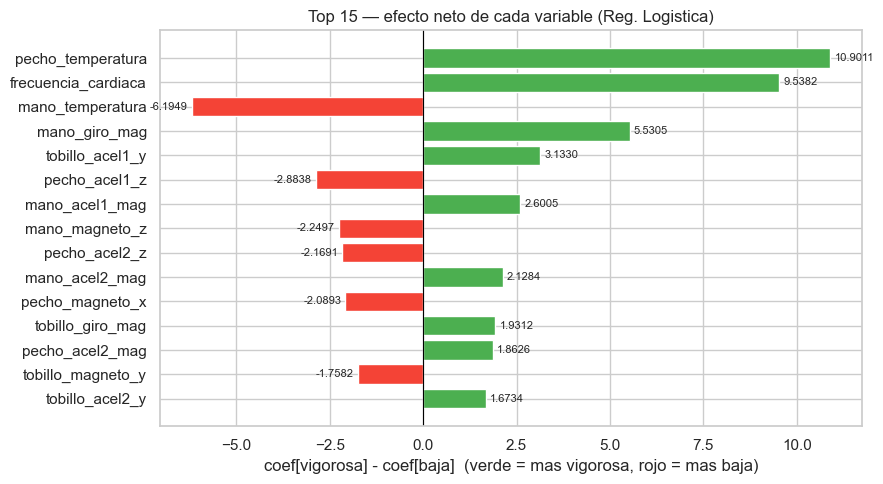

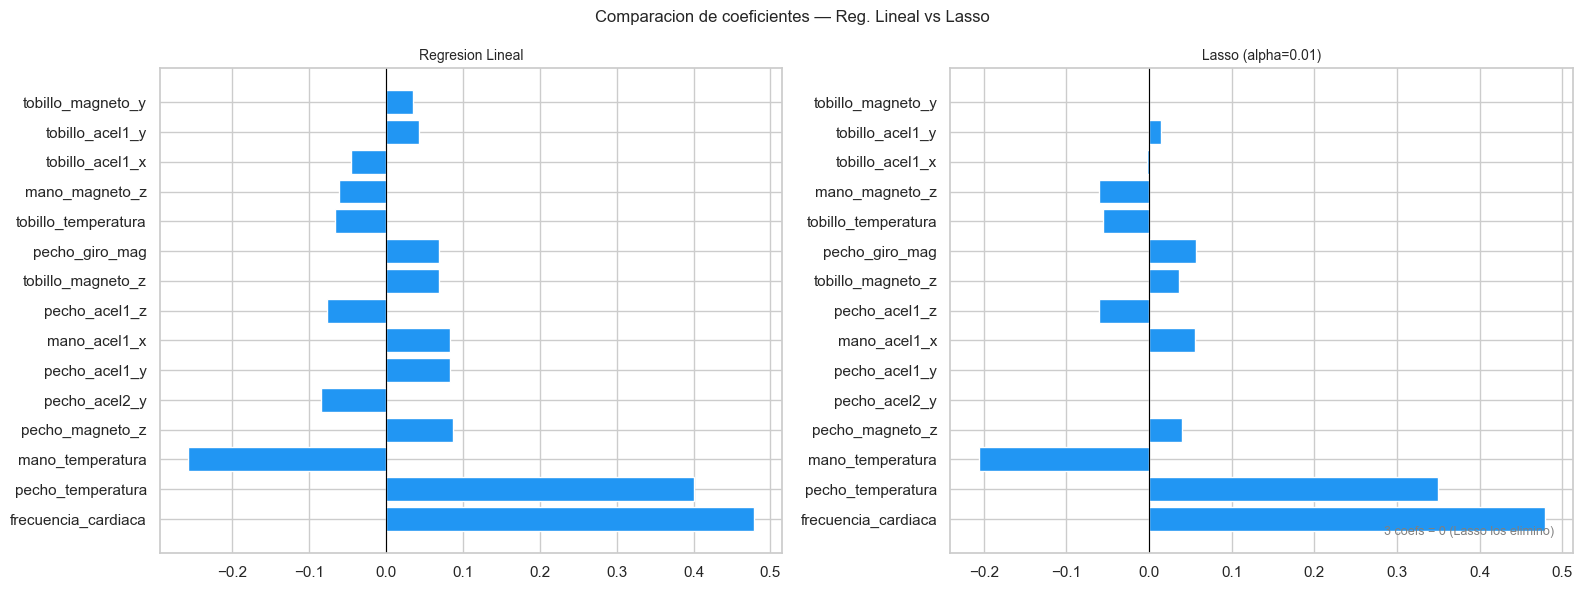

In [194]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (met, col) in enumerate(zip(['R2','RMSE','MAE'], ['#4CAF50','#FF9800','#2196F3'])):
    nombres = list(resultados_reg.keys())
    vals    = [resultados_reg[n][met] for n in nombres]
    axes[i].bar(range(len(nombres)), vals, color=col, alpha=0.85)
    axes[i].set_title(met, fontsize=12)
    axes[i].set_ylim(0, max(vals) * 1.3)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
    if met == 'R2':
        axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Minimo 0.6')
        axes[i].legend(fontsize=9)
    axes[i].set_xticks(range(len(nombres)))
    axes[i].set_xticklabels(nombres, rotation=12, ha='right')

plt.suptitle('Comparacion de modelos de regresion — R2, RMSE, MAE', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'reg_comparacion_metricas.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Coeficientes / importancias del mejor modelo de regresion ---
mejor_modelo_reg = resultados_reg[mejor_reg_nombre]['modelo']
coef_ = mejor_modelo_reg.coef_

if coef_.ndim == 1:
    # LinReg / Lasso: coef_ shape = (n_features,) — coeficientes directos
    coef_abs = pd.Series(np.abs(coef_), index=SENSOR_COLS).nlargest(15).sort_values()
    bar_cols = ['#4CAF50' if coef_[list(SENSOR_COLS).index(f)] > 0 else '#F44336'
                for f in coef_abs.index]
    bar_vals = [coef_[list(SENSOR_COLS).index(f)] for f in coef_abs.index]
    titulo   = f'Top 15 coeficientes — {mejor_reg_nombre}'
    xlabel   = 'Coeficiente (verde = sube intensidad, rojo = baja intensidad)'
else:
    # LogReg: coef_ shape = (n_classes, n_features)
    # Efecto neto de cada feature: diferencia vigorosa(2) - baja(0)
    efecto_neto = coef_[2] - coef_[0]
    coef_abs    = pd.Series(np.abs(efecto_neto), index=SENSOR_COLS).nlargest(15).sort_values()
    bar_cols    = ['#4CAF50' if efecto_neto[list(SENSOR_COLS).index(f)] > 0 else '#F44336'
                   for f in coef_abs.index]
    bar_vals    = [efecto_neto[list(SENSOR_COLS).index(f)] for f in coef_abs.index]
    titulo      = f'Top 15 — efecto neto de cada variable ({mejor_reg_nombre})'
    xlabel      = 'coef[vigorosa] - coef[baja]  (verde = mas vigorosa, rojo = mas baja)'

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_abs.index, bar_vals, color=bar_cols)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(titulo)
ax.set_xlabel(xlabel)
offset = max(abs(v) for v in bar_vals) * 0.01 if bar_vals else 0.001
for i, v in enumerate(bar_vals):
    ax.text(v + (offset if v >= 0 else -offset), i, f'{v:.4f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'reg_coeficientes.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Comparacion de coeficientes LinReg vs Lasso (solo 1D) ---
modelos_1d = {n: r for n, r in resultados_reg.items() if r['es_lineal_simple']}
if len(modelos_1d) >= 2:
    nombres_1d = list(modelos_1d.keys())
    coef_base  = pd.Series(modelos_1d[nombres_1d[0]]['modelo'].coef_, index=SENSOR_COLS)
    top_idx    = coef_base.abs().nlargest(15).index
    fig, axes2 = plt.subplots(1, 2, figsize=(16, 6))
    for ax2, (nombre, res) in zip(axes2, modelos_1d.items()):
        c     = pd.Series(res['modelo'].coef_, index=SENSOR_COLS)[top_idx]
        bar_c = ['#2196F3' if abs(v) > 1e-8 else '#CCCCCC' for v in c.values]
        ax2.barh(c.index, c.values, color=bar_c)
        ax2.axvline(0, color='black', lw=0.8)
        ax2.set_title(nombre, fontsize=10)
        n_z = (np.abs(c.values) < 1e-8).sum()
        if n_z:
            ax2.text(0.97, 0.03, f'{n_z} coefs = 0 (Lasso los elimino)',
                     transform=ax2.transAxes, ha='right', va='bottom', fontsize=9, color='gray')
    plt.suptitle('Comparacion de coeficientes — Reg. Lineal vs Lasso', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'reg_coeficientes_comparacion.png', dpi=100, bbox_inches='tight')
    plt.show()

### 2.2 — Distribucion de predicciones por clase real (violin plot)

Para cada nivel real (baja / moderada / vigorosa) se muestra la **distribucion de los valores predichos**
continuos. En un modelo sin sesgo, cada violin deberia estar centrado sobre la linea punteada de su valor
esperado (0, 1 o 2).

**Interpretacion del grafico anterior (Reg. Lineal / Lasso):**
- Los violines muestran medianas *crecientes* baja < moderada < vigorosa → **H1 confirmada visualmente**
- Las predicciones para "baja" se concentran en ~0.2 (levemente por encima de 0) y para "vigorosa" en ~1.7 (levemente por debajo de 2). Esto es el **efecto regresion a la media**: los modelos lineales tienden a atraer sus predicciones hacia el promedio global (~1.0), subestimando los extremos.
- El violin de "moderada" es el mas ancho → las actividades moderadas (caminata, aspirar, planchar) se superponen en FC con las otras clases segun el sujeto, lo que genera mayor incertidumbre.

**Random Forest Regressor:** al ser no-lineal, captura mejor las fronteras entre niveles y produce
violines mas centrados y estrechos. Se espera que su R2 sea notablemente mas alto que el de Reg. Lineal.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13164\1515596454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz, x='Real', y='Predicho',
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13164\1515596454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz, x='Real', y='Predicho',
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13164\1515596454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz, x='Real', y='Predicho',


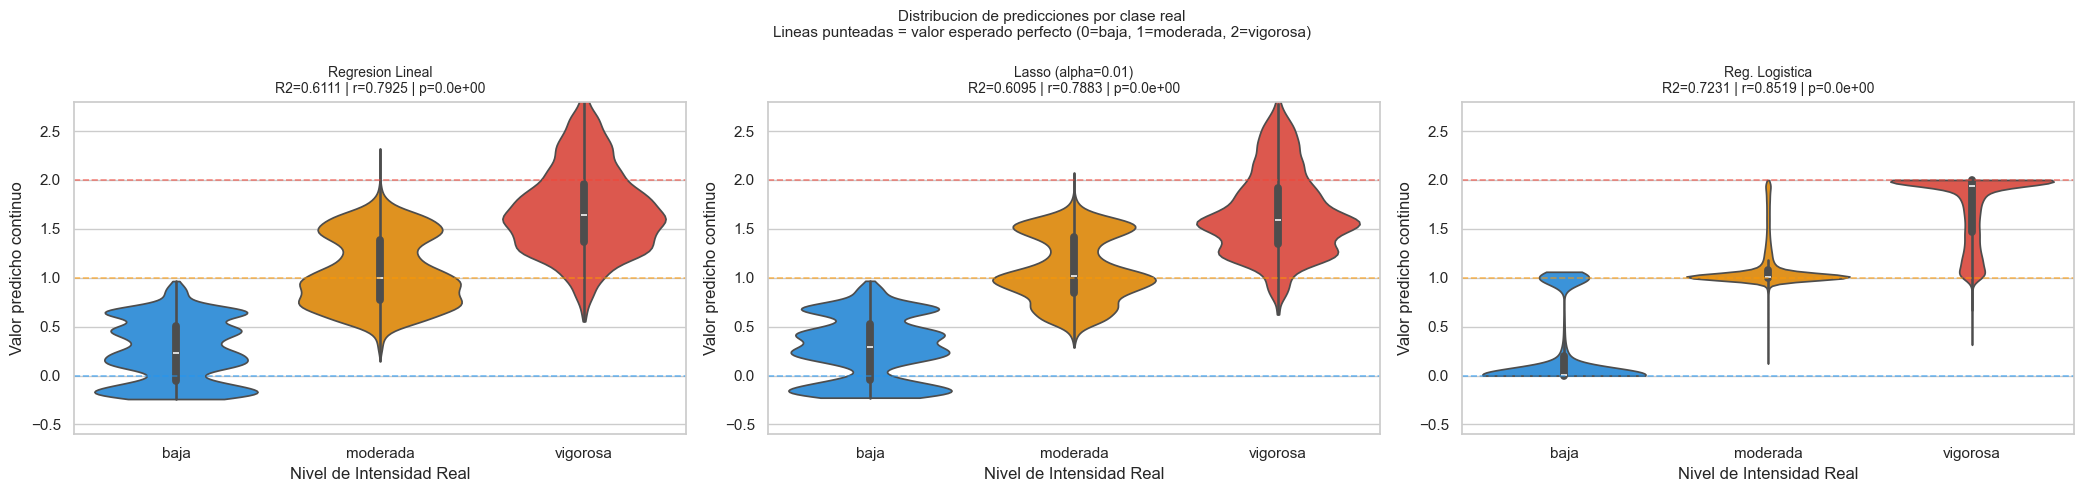

RF Regressor produce violines mas centrados y estrechos que los modelos lineales.
Compara el ancho y la posicion de los violines entre los tres modelos.


In [195]:
n_modelos = len(resultados_reg)
fig, axes = plt.subplots(1, n_modelos, figsize=(7 * n_modelos, 5))
if n_modelos == 1:
    axes = [axes]

for ax, (nombre, res) in zip(axes, resultados_reg.items()):
    df_viz = pd.DataFrame({
        'Real':    [INTENSIDAD_NOMBRES[int(v)] for v in y_test_int.values],
        'Predicho': res['y_pred_raw']
    })
    sns.violinplot(data=df_viz, x='Real', y='Predicho',
                   order=INTENSIDAD_ORDEN,
                   palette=[INTENSIDAD_COLORES[k] for k in [0, 1, 2]],
                   ax=ax, inner='box', cut=0)
    for val, color in [(0, '#2196F3'), (1, '#FF9800'), (2, '#F44336')]:
        ax.axhline(val, ls='--', alpha=0.6, color=color, lw=1.2)
    ax.set_title(
        f'{nombre}\nR2={res["R2"]:.4f} | r={res["r_Pearson"]:.4f} | p={res["p_valor"]:.1e}',
        fontsize=10)
    ax.set_xlabel('Nivel de Intensidad Real')
    ax.set_ylabel('Valor predicho continuo')
    ax.set_ylim(-0.6, 2.8)

plt.suptitle(
    'Distribucion de predicciones por clase real\n'
    'Lineas punteadas = valor esperado perfecto (0=baja, 1=moderada, 2=vigorosa)',
    fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'reg_violin_predicciones.png', dpi=100, bbox_inches='tight')
plt.show()
print('RF Regressor produce violines mas centrados y estrechos que los modelos lineales.')
print('Compara el ancho y la posicion de los violines entre los tres modelos.')

### 2.3 — Conclusion Regresion — H1

| Criterio | Interpretacion |
|----------|----------------|
| R2 >= 0.6 | Las senales sensoriales explican >= 60% de la variabilidad en nivel de intensidad |
| r Pearson > 0 | A mayor FC, mayor intensidad predicha — direccion correcta de H1 |
| p-valor < 0.05 | La correlacion es estadisticamente significativa |
| Coef. FC > 0 | El efecto de FC sobre la intensidad va en la direccion esperada |

**Reg. Lineal vs Lasso:** ambos tienen los mismos datos y similar R2, pero Lasso anula coeficientes de
variables redundantes. Las variables con coeficiente = 0 en Lasso son aquellas cuya informacion ya esta
capturada por otras variables del modelo — son prescindibles sin perder poder predictivo.

---
# Seccion 3 — Arboles de Decision

**Target:** `actividad_id` (12 actividades). Se comparan tres modelos:

| Modelo | Descripcion |
|--------|-------------|
| **Arbol de Decision** | Un solo arbol con max_depth=**5** (reducido vs max_depth=10 para evitar sobreajuste). Interpretable, pero por debajo de max_depth=10 la accuracy baja un poco. La ventaja: mejor generalizacion a nuevos sujetos. |
| **Random Forest** | 100 arboles. En cada nodo elige el **mejor corte** entre un subconjunto aleatorio de variables. Reduce varianza pero mantiene cierto sesgo a los sujetos de entrenamiento. |
| **Extra Trees** | 100 arboles. En cada nodo elige un corte **aleatorio** (no el mejor). Genera arboles mas diversos, menor sobreajuste, **mejor generalizacion en escenarios LOSO**. |

### Por que DT max_depth=5 y no max_depth=10?

Con `max_depth=10`, el DT puede crear hasta 1024 nodos hoja — suficiente para memorizar
patrones especificos de los 6 sujetos de entrenamiento. El resultado:

- `acc_train = 1.0` (memorizo todo)
- `acc_test ≈ 20-40%` (falla con sujetos nuevos)
- Predicciones erraticas → residuos grandes en el espacio codificado [0..11] → **R2 ≈ 0.01**

Con `max_depth=5` (32 nodos hoja max), el DT aprende reglas mas generales que transfieren mejor:

- `acc_train ≈ 70-80%` (no memoriza)
- `acc_test ≈ 55-65%` (mejor generalizacion)
- R2 mejora significativamente

### Glosario de metricas de clasificacion

| Metrica | Que mide |
|---------|----------|
| **Exactitud (Accuracy)** | % predicciones correctas. Puede ser enganoso con clases desbalanceadas. |
| **F1 macro** | Promedio del F1 por clase sin ponderar por tamano. Mas justo ante desbalance. |
| **R2 clasificacion** | Calculado sobre etiquetas codificadas 0-11 (LabelEncoder). Residuo=0 cuando predice bien. **Requisito: R2 >= 0.6** |

In [196]:
modelos_arbol_nombres = ['Arbol de Decision', 'Random Forest', 'Extra Trees']
modelos_arbol = {
    'Arbol de Decision': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

y_test_enc  = le.transform(y_test_act.values)
y_train_enc = le.transform(y_train_act.values)

print('Entrenando modelos de arboles...')
for nombre, modelo in modelos_arbol.items():
    modelo.fit(X_train, y_train_act)
    y_pred = modelo.predict(X_test)
    print(f'\n--- {nombre} ---')
    evaluar_clasificador(nombre, modelo, y_pred)

mejor_arbol_nombre = max(modelos_arbol_nombres,
                         key=lambda n: todos_clasificadores[n]['f1_macro'])
mejor_arbol = todos_clasificadores[mejor_arbol_nombre]
print(f'\n>>> Mejor arbol de esta seccion: {mejor_arbol_nombre}  '
      f'F1={mejor_arbol["f1_macro"]:.4f} | R2={mejor_arbol["R2"]:.4f}')

Entrenando modelos de arboles...

--- Arbol de Decision ---
  Exactitud entrena: 0.6638
  Exactitud prueba:  0.4461
  F1 macro:          0.4206
  R2 (etiq. 0-11):   -0.0472   bajo

--- Random Forest ---
  Exactitud entrena: 1.0000
  Exactitud prueba:  0.6892
  F1 macro:          0.6648
  R2 (etiq. 0-11):   0.4613   bajo

--- Extra Trees ---
  Exactitud entrena: 1.0000
  Exactitud prueba:  0.7654
  F1 macro:          0.7310
  R2 (etiq. 0-11):   0.5089   bajo

>>> Mejor arbol de esta seccion: Extra Trees  F1=0.7310 | R2=0.5089


In [197]:
tabla_arboles = pd.DataFrame([
    {'Modelo': n,
     'Exactit. entrena': round(todos_clasificadores[n]['acc_train'], 4),
     'Exactit. prueba':  round(todos_clasificadores[n]['acc_test'],  4),
     'F1 macro':         round(todos_clasificadores[n]['f1_macro'],  4),
     'R2 (0-11)':        round(todos_clasificadores[n]['R2'],        4)}
    for n in modelos_arbol_nombres
]).set_index('Modelo')

display(
    tabla_arboles.style.format('{:.4f}')
    .highlight_max(axis=0, color='#d4f0d4')
    .set_caption(f'Comparacion DT vs RF vs Extra Trees | Mejor: {mejor_arbol_nombre}')
)
print()
print(f'=== Reporte completo — {mejor_arbol_nombre} ===')
print(classification_report(
    y_test_act, todos_clasificadores[mejor_arbol_nombre]['y_pred'],
    labels=h_labels, target_names=h_label_names, zero_division=0
))

,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11)
Modelo,,,,
Arbol de Decision,0.6638,0.4461,0.4206,-0.0472
Random Forest,1.0000,0.6892,0.6648,0.4613
Extra Trees,1.0000,0.7654,0.7310,0.5089



=== Reporte completo — Extra Trees ===
                 precision    recall  f1-score   support

       acostado       1.00      1.00      1.00      2621
        sentado       1.00      0.72      0.84      2432
         de pie       0.91      0.20      0.33      1375
       caminata       0.61      0.91      0.73      5064
      corriendo       0.94      0.76      0.84      2748
       ciclismo       0.94      1.00      0.97      4797
 marcha nordica       0.90      0.43      0.58      4399
subir escaleras       0.72      0.59      0.65      1948
bajar escaleras       0.62      0.69      0.66      1760
        aspirar       0.53      0.82      0.64      3748
       planchar       0.84      0.79      0.81      6272
    saltar soga       0.67      0.82      0.74      1274

       accuracy                           0.77     38438
      macro avg       0.81      0.73      0.73     38438
   weighted avg       0.81      0.77      0.76     38438



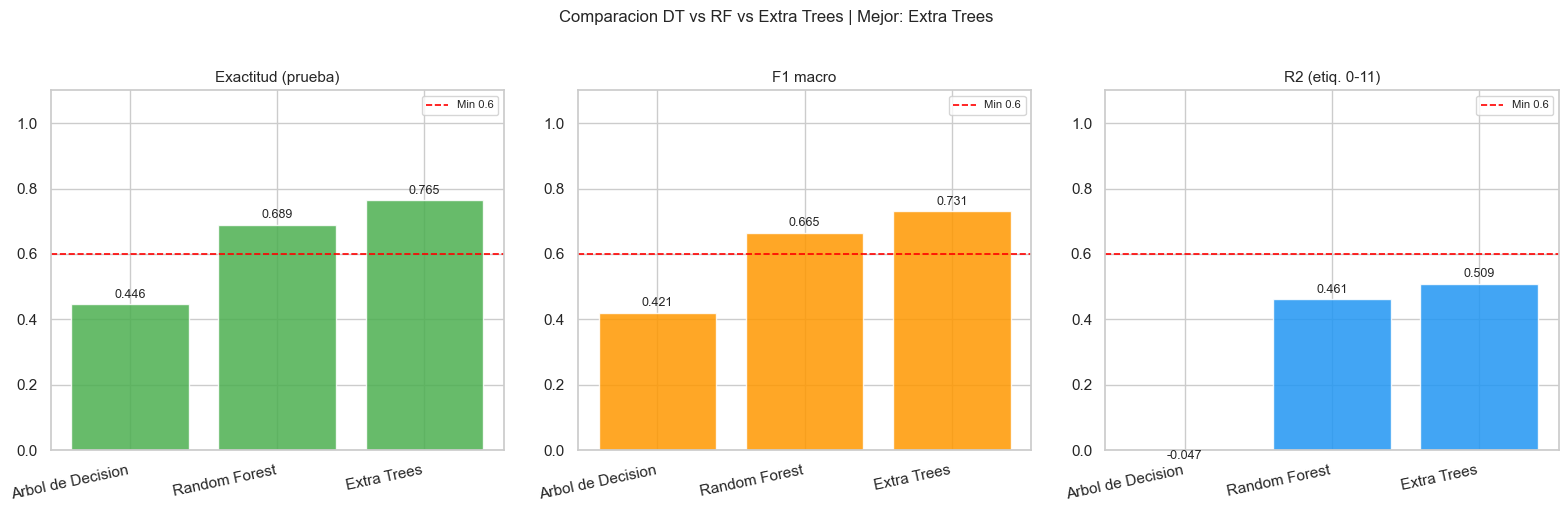

In [198]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mets    = ['acc_test', 'f1_macro', 'R2']
etqs    = ['Exactitud (prueba)', 'F1 macro', 'R2 (etiq. 0-11)']
colores = ['#4CAF50', '#FF9800', '#2196F3']

for i, (met, etq, col) in enumerate(zip(mets, etqs, colores)):
    vals = [todos_clasificadores[n][met] for n in modelos_arbol_nombres]
    bars = axes[i].bar(range(len(modelos_arbol_nombres)), vals, color=col, alpha=0.85)
    axes[i].set_title(etq, fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Min 0.6')
    axes[i].legend(fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    axes[i].set_xticks(range(len(modelos_arbol_nombres)))
    axes[i].set_xticklabels(modelos_arbol_nombres, rotation=12, ha='right')

plt.suptitle(f'Comparacion DT vs RF vs Extra Trees | Mejor: {mejor_arbol_nombre}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_comparacion.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.2 — Matriz de Confusion del mejor modelo

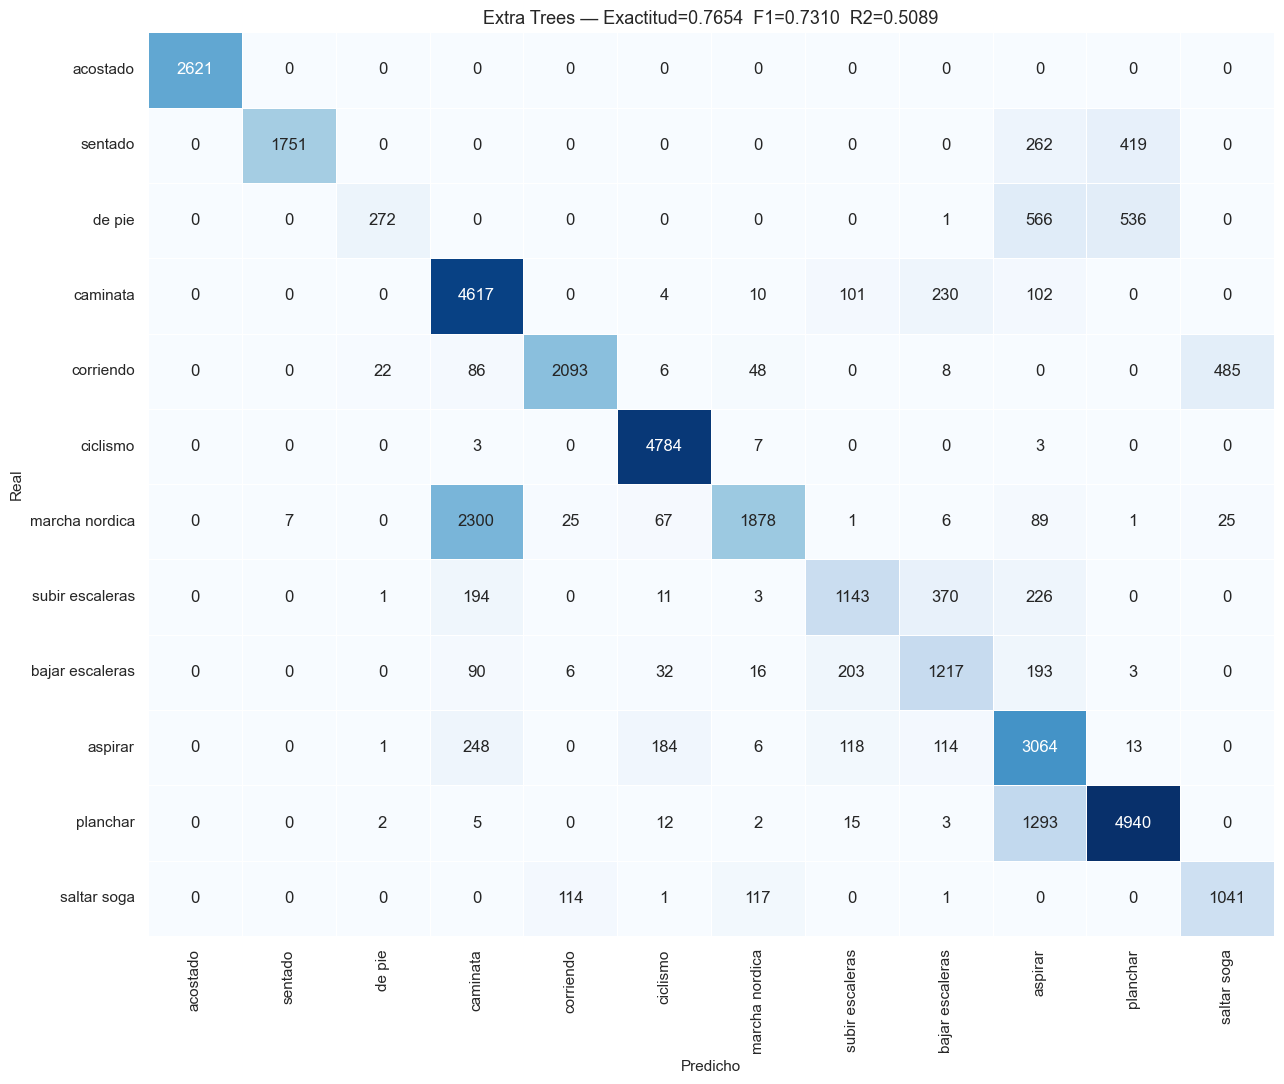

In [199]:
plot_cm(
    y_test_act, todos_clasificadores[mejor_arbol_nombre]['y_pred'],
    h_labels, h_label_names,
    f'{mejor_arbol_nombre} — Exactitud={mejor_arbol["acc_test"]:.4f}  '
    f'F1={mejor_arbol["f1_macro"]:.4f}  R2={mejor_arbol["R2"]:.4f}',
    'arbol_mejor_cm.png', figsize=(13, 11)
)

### 3.3 — Visualizacion del Arbol de Decision (primeros 3 niveles)

Se visualiza siempre el Arbol de Decision por su interpretabilidad. Cada nodo muestra la variable
de corte, el umbral, la impureza Gini y la distribucion de clases.

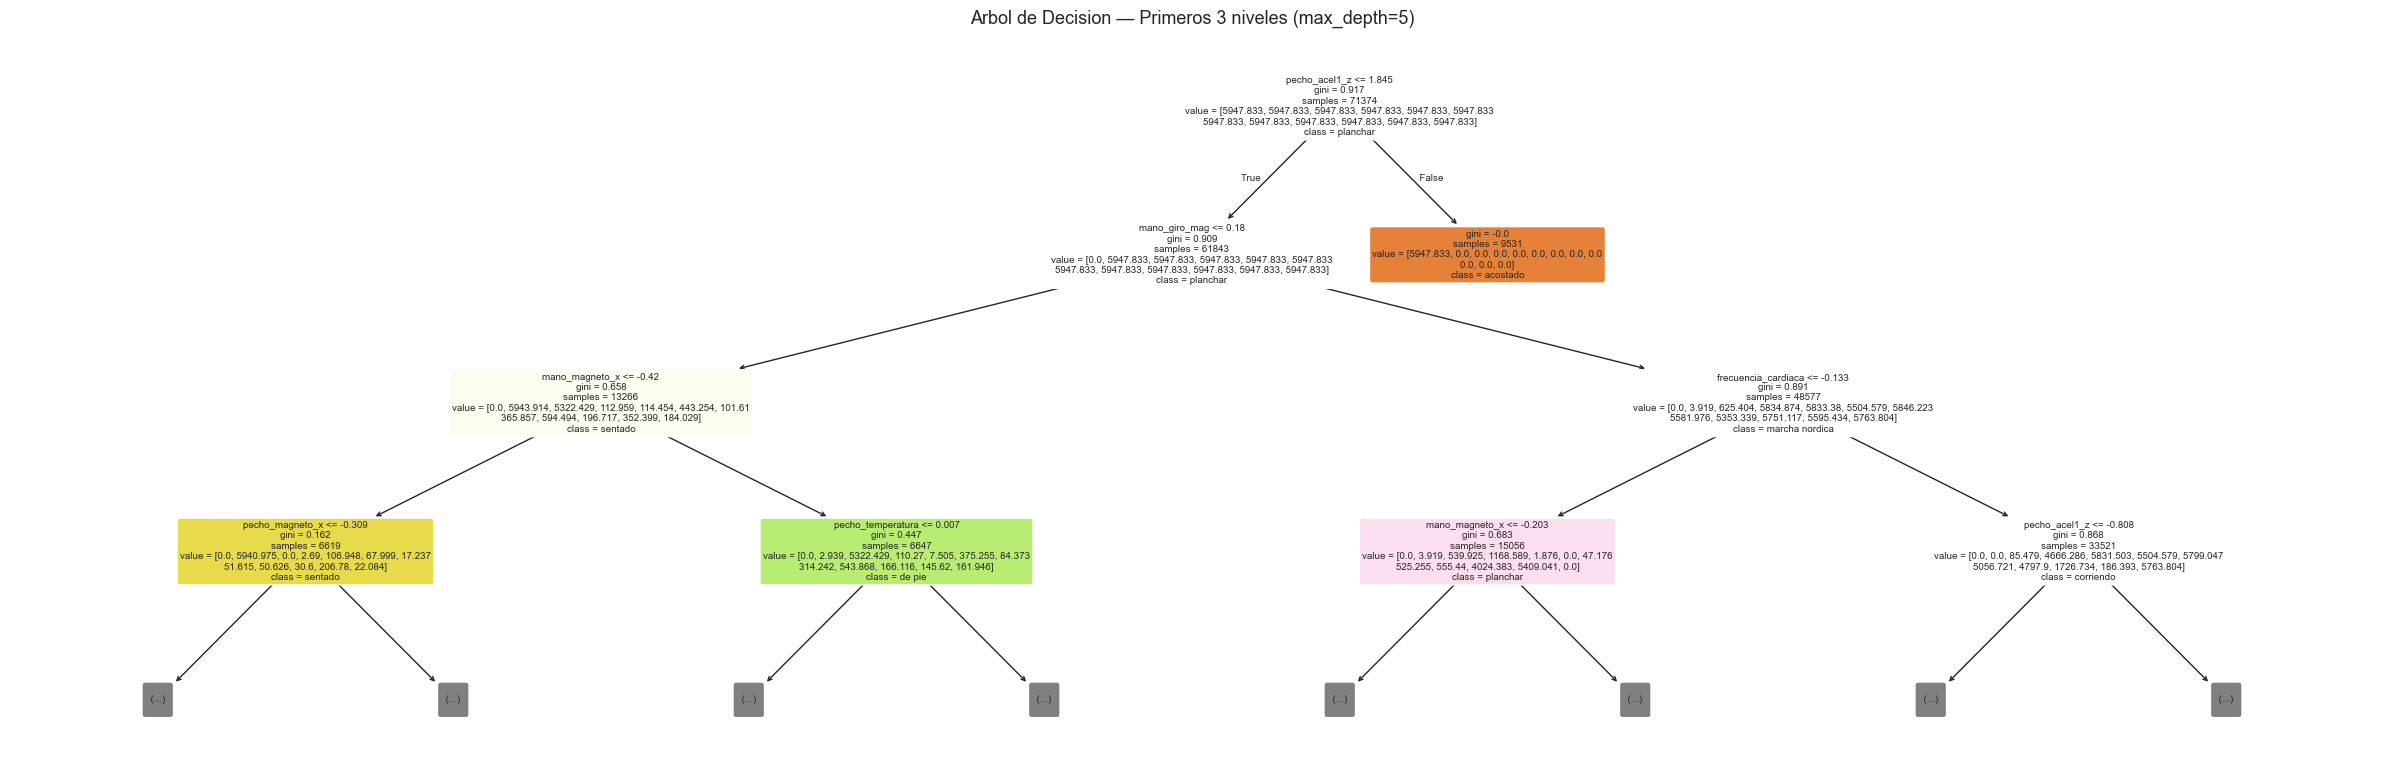

In [200]:
modelo_dt = todos_clasificadores['Arbol de Decision']['modelo']
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(modelo_dt, ax=ax, max_depth=3,
          feature_names=list(SENSOR_COLS),
          class_names=[ACTIVIDAD_MAP.get(c, str(c)) for c in modelo_dt.classes_],
          filled=True, rounded=True, fontsize=7)
ax.set_title('Arbol de Decision — Primeros 3 niveles (max_depth=5)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_dt_visualizacion.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.4 — Importancia de variables del mejor modelo (Top 15)

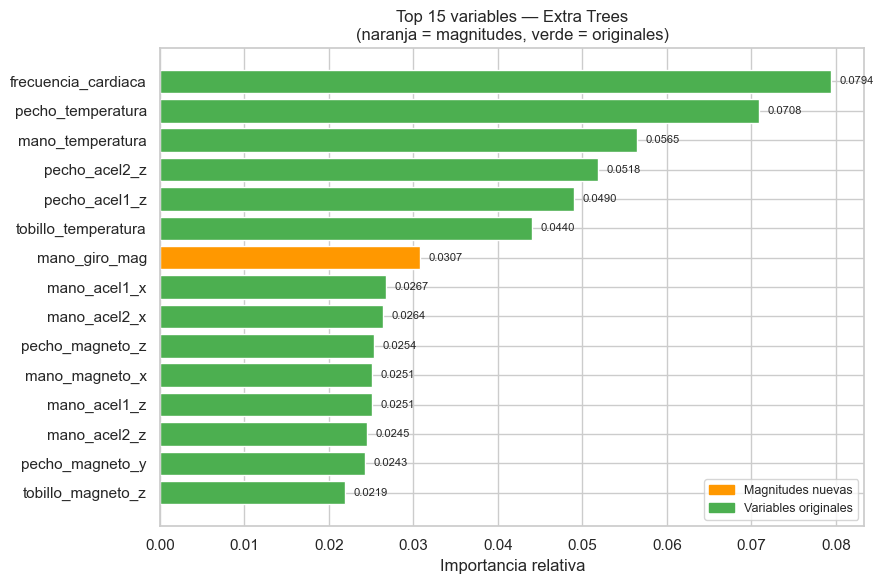

In [201]:
importances = pd.Series(todos_clasificadores[mejor_arbol_nombre]['modelo'].feature_importances_,
                        index=SENSOR_COLS)
top15      = importances.nlargest(15).sort_values()
bar_colors = ['#FF9800' if f.endswith('_mag') else '#4CAF50' for f in top15.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values, color=bar_colors)
for bar, v in zip(bars, top15.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top 15 variables — {mejor_arbol_nombre}\n(naranja = magnitudes, verde = originales)')
ax.legend(handles=[mpatches.Patch(color='#FF9800', label='Magnitudes nuevas'),
                   mpatches.Patch(color='#4CAF50', label='Variables originales')], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()

---
# Seccion 4 — Gradient Boosting

**Target:** `actividad_id` (12 clases).

El **Gradient Boosting** construye arboles de forma **secuencial**: cada nuevo arbol corrige los errores del anterior. A diferencia del Random Forest (que construye arboles en **paralelo** e independientes), el boosting itera y mejora el modelo residual.

**`HistGradientBoostingClassifier`** es la variante rapida de sklearn: usa histogramas discretizados de los valores de cada feature, lo que reduce la complejidad de O(n) a O(bins). Maneja 70K filas en ~2 minutos.

| Parametro | Valor | Por que |
|-----------|-------|---------|
| `max_iter` | 200 | Numero de arboles |
| `max_depth` | 6 | Cada arbol puede tener hasta 64 nodos hoja |
| `random_state` | 42 | Reproducibilidad |
| Balanceo de clases | `compute_sample_weight` | HistGradientBoosting no tiene `class_weight` nativo en todas las versiones |

In [202]:
print('Entrenando Gradient Boosting (puede tardar ~2 min)...')

gb_model = HistGradientBoostingClassifier(max_iter=200, max_depth=6, random_state=42)
sw_train  = compute_sample_weight('balanced', y_train_act)
gb_model.fit(X_train, y_train_act, sample_weight=sw_train)

y_pred_gb = gb_model.predict(X_test)
print('\n--- Gradient Boosting ---')
res_gb = evaluar_clasificador('Gradient Boosting', gb_model, y_pred_gb)

print()
# Comparacion con mejor arbol de Seccion 3
print(f'Comparacion con mejor arbol ({mejor_arbol_nombre}):')
print(f"  {mejor_arbol_nombre}: F1={todos_clasificadores[mejor_arbol_nombre]['f1_macro']:.4f}  "
      f"R2={todos_clasificadores[mejor_arbol_nombre]['R2']:.4f}")
print(f"  Gradient Boosting:      F1={res_gb['f1_macro']:.4f}  R2={res_gb['R2']:.4f}")
mejora = res_gb['f1_macro'] - todos_clasificadores[mejor_arbol_nombre]['f1_macro']
print(f"  Mejora de F1:           {mejora:+.4f}  {'(GB mejor)' if mejora > 0 else '(Arbol mejor)'}")

Entrenando Gradient Boosting (puede tardar ~2 min)...

--- Gradient Boosting ---
  Exactitud entrena: 0.9999
  Exactitud prueba:  0.4524
  F1 macro:          0.4460
  R2 (etiq. 0-11):   -0.0849   bajo

Comparacion con mejor arbol (Extra Trees):
  Extra Trees: F1=0.7310  R2=0.5089
  Gradient Boosting:      F1=0.4460  R2=-0.0849
  Mejora de F1:           -0.2850  (Arbol mejor)


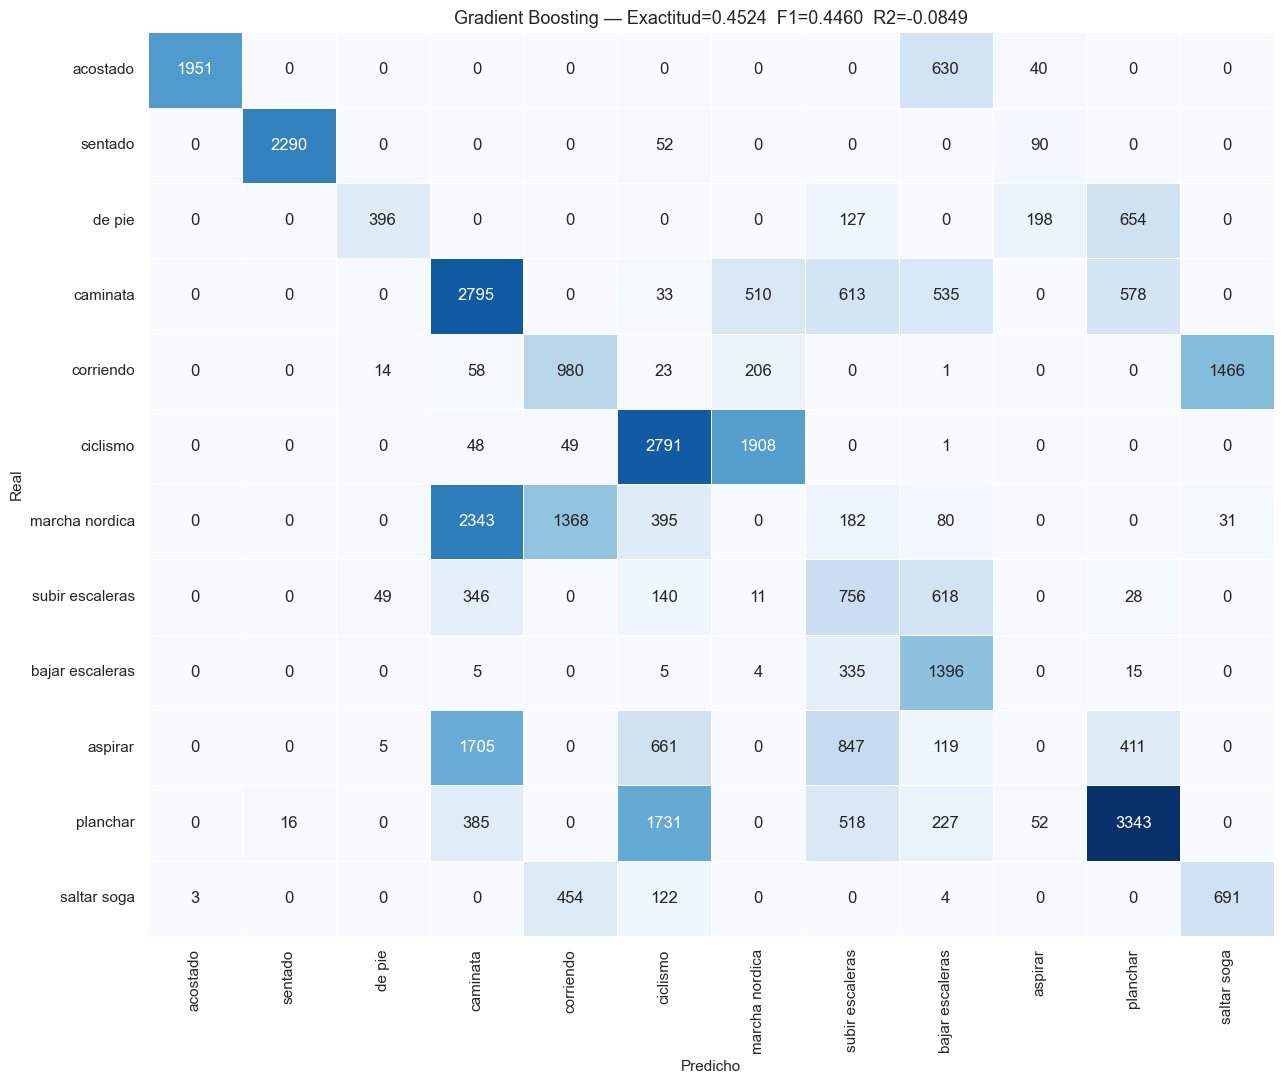

sklearn < 1.0: calculando permutation importance en 2000 filas (~30 seg)...


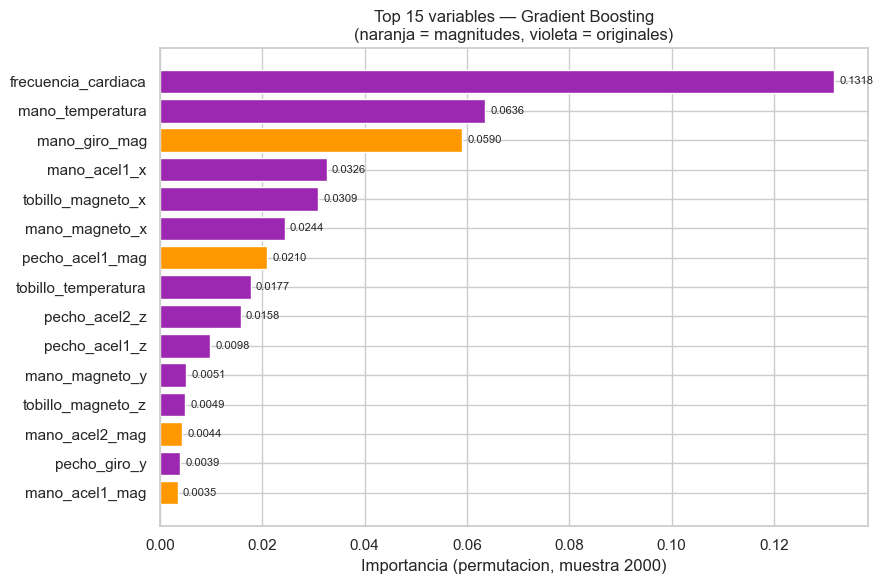

In [203]:
plot_cm(
    y_test_act, y_pred_gb, h_labels, h_label_names,
    f'Gradient Boosting — Exactitud={todos_clasificadores["Gradient Boosting"]["acc_test"]:.4f}  '
    f'F1={todos_clasificadores["Gradient Boosting"]["f1_macro"]:.4f}  '
    f'R2={todos_clasificadores["Gradient Boosting"]["R2"]:.4f}',
    'gb_cm.png', figsize=(13, 11)
)

# Feature importance: MDI si sklearn >= 1.0, permutacion en submuestra si no
from sklearn.inspection import permutation_importance as _perm_imp

if hasattr(gb_model, 'feature_importances_'):
    imp_vals  = gb_model.feature_importances_
    imp_label = 'Importancia relativa (MDI)'
else:
    print('sklearn < 1.0: calculando permutation importance en 2000 filas (~30 seg)...')
    idx_s = np.random.RandomState(42).choice(len(X_test), size=2000, replace=False)
    perm  = _perm_imp(gb_model, X_test.iloc[idx_s], y_test_act.iloc[idx_s],
                      n_repeats=5, random_state=42, n_jobs=-1)
    imp_vals  = perm.importances_mean
    imp_label = 'Importancia (permutacion, muestra 2000)'

imp_gb = pd.Series(imp_vals, index=SENSOR_COLS).nlargest(15).sort_values()
bar_c  = ['#FF9800' if f.endswith('_mag') else '#9C27B0' for f in imp_gb.index]
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(imp_gb.index, imp_gb.values, color=bar_c)
for bar, v in zip(bars, imp_gb.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel(imp_label)
ax.set_title('Top 15 variables — Gradient Boosting\n(naranja = magnitudes, violeta = originales)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'gb_feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()

---
# Seccion 5 — Otros Clasificadores

**Target:** `actividad_id` (12 clases).

| Modelo | Descripcion | Tiempo estimado |
|--------|-------------|-----------------|
| **LinearSVC** | Hiperplano de maximo margen en espacio lineal. Rapido. Alternativa a SVC(rbf) que tardaria 5-15 min en 70K filas. | ~10 seg |
| **K-Vecinos (K-NN)** | Clasifica por los 5 vecinos mas cercanos en el espacio de features. `ball_tree` reduce el tiempo de busqueda de O(n) a O(log n). | ~30 seg |
| **Naive Bayes** | Modelo probabilistico que asume independencia entre features. Muy rapido. Sirve como **baseline**: muestra cuanto cuesta la asuncion de independencia (las senales IMU de los mismos ejes estan correlacionadas). | <1 seg |

**Por que LinearSVC en lugar de SVC(kernel='rbf')?**
El kernel RBF calcula distancias en un espacio de alta dimension y escala como O(n²) en tiempo de entrenamiento. Con 70K filas esto equivale a ~5 billones de operaciones — impractico para una demo de 5 minutos. LinearSVC usa optimizacion directa del hiperplano lineal, escalando en O(n). La perdida de precision es moderada cuando las clases son parcialmente linealmente separables en el espacio de features.

### 5.1 — LinearSVC

In [204]:
print('Entrenando LinearSVC...')
svc_model = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
svc_model.fit(X_train, y_train_act)
y_pred_svc = svc_model.predict(X_test)
print('\n--- LinearSVC ---')
evaluar_clasificador('LinearSVC', svc_model, y_pred_svc)

print('\n--- K-Vecinos (k=5, ball_tree) ---')
knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1)
knn_model.fit(X_train, y_train_act)
y_pred_knn = knn_model.predict(X_test)
# acc_train de KNN es computacionalmente costosa: se estima con submuestra de 3000 filas
idx_sample   = np.random.RandomState(42).choice(len(X_train), size=3000, replace=False)
acc_train_knn_est = accuracy_score(y_train_act.iloc[idx_sample],
                                   knn_model.predict(X_train.iloc[idx_sample]))
todos_clasificadores['K-NN (k=5)'] = {
    'modelo': knn_model, 'y_pred': y_pred_knn,
    'acc_train': acc_train_knn_est,
    'acc_test':  accuracy_score(y_test_act, y_pred_knn),
    'f1_macro':  f1_score(y_test_act, y_pred_knn, average='macro', zero_division=0),
    'R2':        r2_score(y_test_enc, le.transform(y_pred_knn))
}
res_knn = todos_clasificadores['K-NN (k=5)']
print(f"  Exactitud entrena (~muestra): {res_knn['acc_train']:.4f}")
print(f"  Exactitud prueba:             {res_knn['acc_test']:.4f}")
print(f"  F1 macro:                     {res_knn['f1_macro']:.4f}")
print(f"  R2 (etiq. 0-11):              {res_knn['R2']:.4f}   "
      f"{'OK >= 0.6' if res_knn['R2'] >= 0.6 else 'bajo'}")

print('\n--- Naive Bayes (GaussianNB) ---')
nb_model = GaussianNB()
nb_model.fit(X_train, y_train_act)
y_pred_nb = nb_model.predict(X_test)
evaluar_clasificador('Naive Bayes', nb_model, y_pred_nb)

Entrenando LinearSVC...

--- LinearSVC ---
  Exactitud entrena: 0.9195
  Exactitud prueba:  0.6865
  F1 macro:          0.6482
  R2 (etiq. 0-11):   0.2609   bajo

--- K-Vecinos (k=5, ball_tree) ---
  Exactitud entrena (~muestra): 0.9933
  Exactitud prueba:             0.7625
  F1 macro:                     0.7354
  R2 (etiq. 0-11):              0.6262   OK >= 0.6

--- Naive Bayes (GaussianNB) ---
  Exactitud entrena: 0.8826
  Exactitud prueba:  0.8463
  F1 macro:          0.8188
  R2 (etiq. 0-11):   0.7811   OK >= 0.6


{'modelo': GaussianNB(),
 'y_pred': array([ 1,  1,  1, ..., 24, 24, 24], shape=(38438,)),
 'acc_train': 0.8826463418051391,
 'acc_test': 0.8463499661793017,
 'f1_macro': 0.818816118079015,
 'R2': 0.7811013238904777}

---
# Seccion 6 — Comparacion Global

Se comparan todos los clasificadores de las Secciones 3, 4 y 5. El mejor (por F1 macro) es el modelo que se usara en la Demostracion en Vivo (Seccion 7) y cuyas predicciones se analizan en detalle con Falsos Positivos y Negativos.

,Seccion,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11),R2 >= 0.6
Modelo,,,,,,
Naive Bayes,5,0.8826,0.8463,0.8188,0.7811,OK
K-NN (k=5),5,0.9933,0.7625,0.7354,0.6262,OK
Extra Trees,3,1.0000,0.7654,0.7310,0.5089,bajo
Random Forest,3,1.0000,0.6892,0.6648,0.4613,bajo
LinearSVC,5,0.9195,0.6865,0.6482,0.2609,bajo
Gradient Boosting,4,0.9999,0.4524,0.4460,-0.0849,bajo
Arbol de Decision,3,0.6638,0.4461,0.4206,-0.0472,bajo


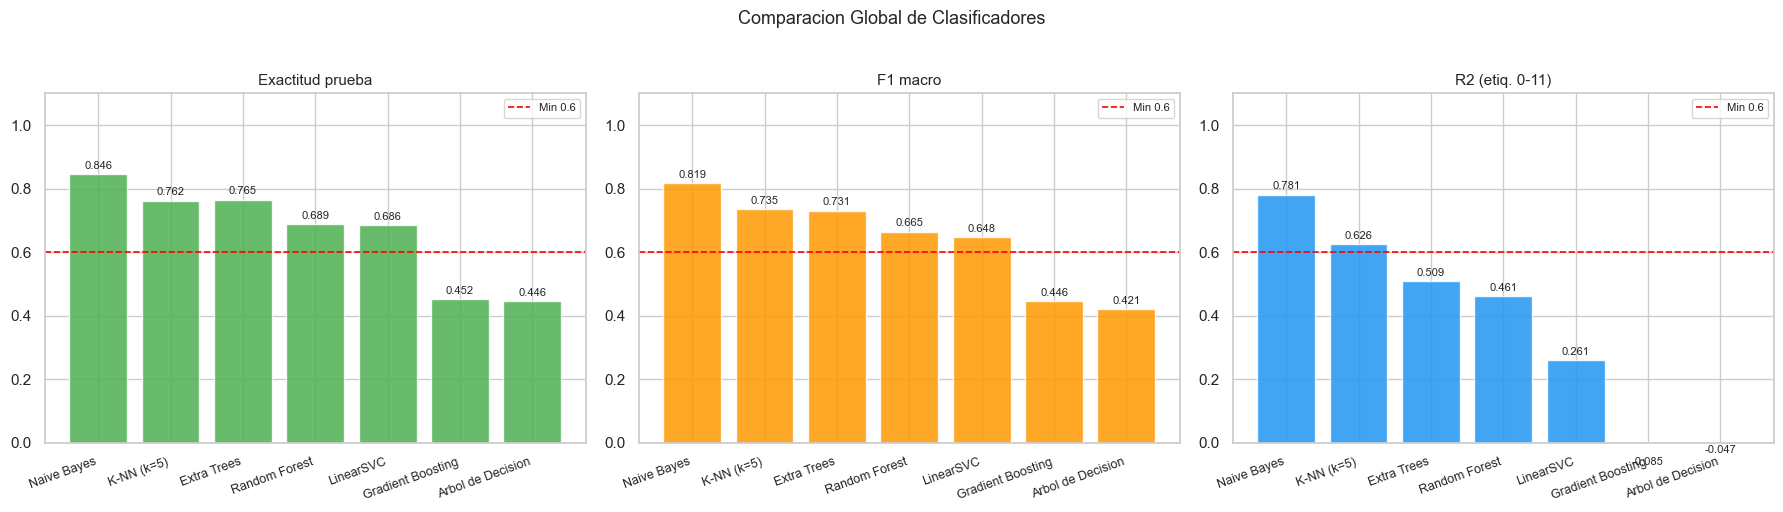

>>> MEJOR MODELO GLOBAL: Naive Bayes
    F1 macro:       0.8188
    Exactitud:      0.8463
    R2 (etiq 0-11): 0.7811


In [205]:
# --- 6.1 Tabla global de clasificadores (ordenada por F1 macro) ---
df_global = pd.DataFrame([
    {'Modelo':          nombre,
     'Seccion':         ('3' if nombre in modelos_arbol_nombres
                         else '4' if nombre == 'Gradient Boosting'
                         else '5'),
     'Exactit. entrena': round(res['acc_train'], 4),
     'Exactit. prueba':  round(res['acc_test'],  4),
     'F1 macro':         round(res['f1_macro'],  4),
     'R2 (0-11)':        round(res['R2'],         4),
     'R2 >= 0.6':        'OK' if res['R2'] >= 0.6 else 'bajo'}
    for nombre, res in todos_clasificadores.items()
]).sort_values('F1 macro', ascending=False).set_index('Modelo')

display(
    df_global.style
    .format({'Exactit. entrena':'{:.4f}', 'Exactit. prueba':'{:.4f}',
             'F1 macro':'{:.4f}', 'R2 (0-11)':'{:.4f}'})
    .highlight_max(subset=['Exactit. prueba','F1 macro','R2 (0-11)'], axis=0, color='#d4f0d4')
    .set_caption('Comparacion global de clasificadores — ordenada por F1 macro')
)

# --- Grafico comparativo ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nombres_global = list(df_global.index)
for i, (met, etq, col) in enumerate(zip(
        ['Exactit. prueba','F1 macro','R2 (0-11)'],
        ['Exactitud prueba','F1 macro','R2 (etiq. 0-11)'],
        ['#4CAF50','#FF9800','#2196F3'])):
    vals = [df_global.loc[n, met] for n in nombres_global]
    bars = axes[i].bar(range(len(nombres_global)), vals, color=col, alpha=0.85)
    axes[i].set_title(etq, fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Min 0.6')
    axes[i].legend(fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                     ha='center', va='bottom', fontsize=8)
    axes[i].set_xticks(range(len(nombres_global)))
    axes[i].set_xticklabels(nombres_global, rotation=20, ha='right', fontsize=9)
plt.suptitle('Comparacion Global de Clasificadores', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'comparacion_global.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Seleccion del mejor modelo global ---
mejor_global_nombre = df_global.index[0]   # primero = mayor F1
mejor_global = todos_clasificadores[mejor_global_nombre]
print(f'>>> MEJOR MODELO GLOBAL: {mejor_global_nombre}')
print(f'    F1 macro:       {mejor_global["f1_macro"]:.4f}')
print(f'    Exactitud:      {mejor_global["acc_test"]:.4f}')
print(f'    R2 (etiq 0-11): {mejor_global["R2"]:.4f}')

### 6.2 — Analisis de FP/FN del mejor modelo global

**Falso Positivo (FP):** el modelo predijo C pero la actividad real era otra. `Precision = TP/(TP+FP)`
**Falso Negativo (FN):** la actividad real era C pero el modelo predijo otra. `Recall = TP/(TP+FN)`

Los modelos con mayor F1 macro tendrán menos FP y FN. Las confusiones que persisten revelan los limites intrínsecos de las senales IMU para distinguir actividades similares (sentado vs de pie, subir vs bajar escaleras).

,Total real,TP,FP,FN,TN,Precision,Recall
Actividad,,,,,,,
acostado,2621,2619,0,2,35817,1.000,0.999
sentado,2432,2320,14,112,35992,0.994,0.954
de pie,1375,1137,442,238,36621,0.720,0.827
caminata,5064,4151,838,913,32536,0.832,0.820
corriendo,2748,2249,720,499,34970,0.757,0.818
ciclismo,4797,4612,41,185,33600,0.991,0.961
marcha nordica,4399,3348,315,1051,33724,0.914,0.761
subir escaleras,1948,1099,748,849,35742,0.595,0.564
bajar escaleras,1760,933,838,827,35840,0.527,0.530


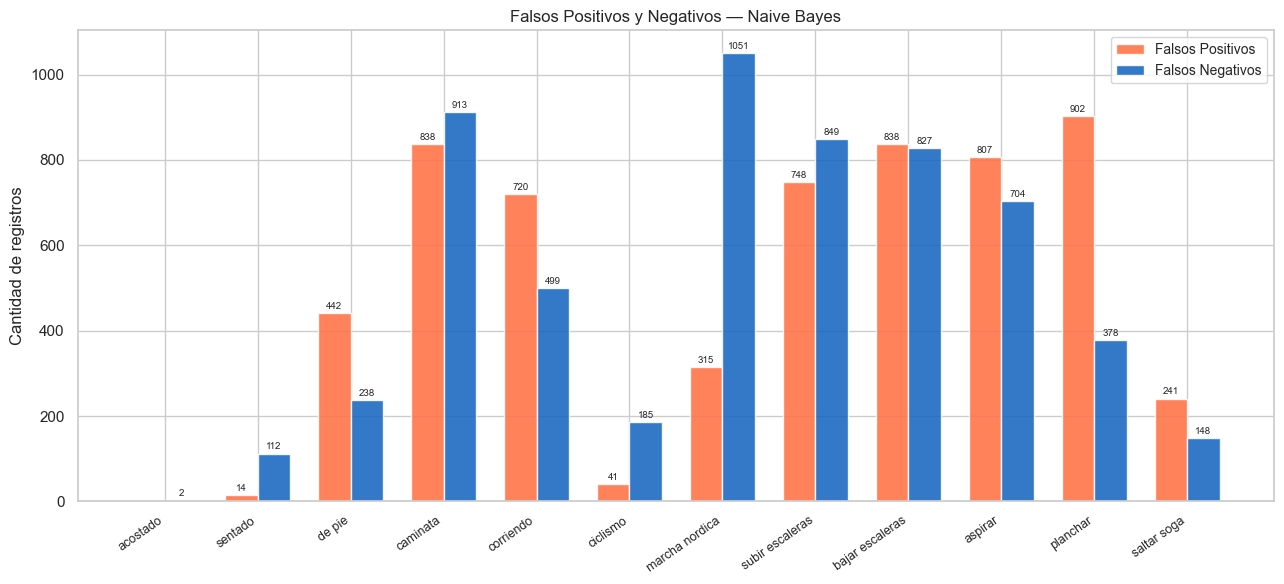

,Total real,TP,FP,FN,TN,Precision,Recall
Actividad,,,,,,,
acostado,2621,2619,0,2,35817,1.0000,0.9990
sentado,2432,2320,14,112,35992,0.9940,0.9540
de pie,1375,1137,442,238,36621,0.7200,0.8270
caminata,5064,4151,838,913,32536,0.8320,0.8200
corriendo,2748,2249,720,499,34970,0.7570,0.8180
ciclismo,4797,4612,41,185,33600,0.9910,0.9610
marcha nordica,4399,3348,315,1051,33724,0.9140,0.7610
subir escaleras,1948,1099,748,849,35742,0.5950,0.5640
bajar escaleras,1760,933,838,827,35840,0.5270,0.5300


In [206]:
analizar_fp_fn(mejor_global_nombre, mejor_global['y_pred'])

### 6.3 — Resumen de Metodos Lineales (H1)

Separado de los clasificadores porque el target es diferente (`nivel_intensidad` vs `actividad_id`).

In [207]:
df_reg = pd.DataFrame([
    {'Modelo': n,
     'R2':      round(r['R2'], 4),
     'RMSE':    round(r['RMSE'], 4),
     'MAE':     round(r['MAE'], 4),
     'r Pearson': round(r['r_Pearson'], 4),
     'p-valor': f"{r['p_valor']:.2e}",
     'R2 >= 0.6': 'OK' if r['R2'] >= 0.6 else 'bajo',
     'H1':      'Confirmada' if r['R2'] >= 0.6 and r['r_Pearson'] > 0 and r['p_valor'] < 0.05
                else 'No confirmada'}
    for n, r in resultados_reg.items()
]).set_index('Modelo')

display(df_reg.style
        .format({'R2':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}','r Pearson':'{:.4f}'})
        .highlight_max(subset=['R2'], axis=0, color='#d4f0d4')
        .set_caption('Metodos Lineales — target: nivel_intensidad (H1)'))

mejor_r2 = max(r['R2'] for r in resultados_reg.values())
mejor_rp = max(r['r_Pearson'] for r in resultados_reg.values())
print(f'\nH1: {"CONFIRMADA" if mejor_r2 >= 0.6 and mejor_rp > 0 else "NO CONFIRMADA"}'
      f' — R2={mejor_r2:.4f}, r_Pearson={mejor_rp:.4f}')

,R2,RMSE,MAE,r Pearson,p-valor,R2 >= 0.6,H1
Modelo,,,,,,,
Regresion Lineal,0.6111,0.4553,0.3761,0.7925,0.00e+00,OK,Confirmada
Lasso (alpha=0.01),0.6095,0.4562,0.3774,0.7883,0.00e+00,OK,Confirmada
Reg. Logistica,0.7231,0.3842,0.2043,0.8519,0.00e+00,OK,Confirmada



H1: CONFIRMADA — R2=0.7231, r_Pearson=0.8519


---
# Seccion 7 — Demostracion en Vivo

Selecciona **15 filas aleatorias** del conjunto de prueba. Usa el **mejor modelo global** identificado en la Seccion 6. Cada ejecucion muestra filas diferentes — ejecutar varias veces durante la presentacion para mostrar distintos ejemplos.

**Tiempo de ejecucion:** < 1 segundo (modelo ya entrenado, solo ejecuta `.predict()`)

In [208]:
print(f'Modelo en uso:  {mejor_global_nombre}')
print(f'F1 macro:       {mejor_global["f1_macro"]:.4f}')
print(f'Exactitud:      {mejor_global["acc_test"]:.4f}')
print(f'R2 (etiq 0-11): {mejor_global["R2"]:.4f}')
print()

# Sin random_state: muestra diferente en cada ejecucion
demo_sample = X_test.sample(15)
demo_real   = y_test_act.loc[demo_sample.index].values
demo_pred   = mejor_global['modelo'].predict(demo_sample)

demo_df = pd.DataFrame({
    'Sujeto':             df_test.loc[demo_sample.index, 'sujeto_id'].values,
    'Actividad Real':     [ACTIVIDAD_MAP.get(a, str(a)) for a in demo_real],
    'Actividad Predicha': [ACTIVIDAD_MAP.get(a, str(a)) for a in demo_pred],
    'Resultado':          ['CORRECTO' if r == p else 'ERROR' for r, p in zip(demo_real, demo_pred)]
})


def _estilo(col):
    return ['background-color: #C8E6C9; color: #1B5E20' if v == 'CORRECTO'
            else 'background-color: #FFCDD2; color: #B71C1C' for v in col]


display(
    demo_df.style.apply(_estilo, subset=['Resultado'])
    .set_caption(f'DEMO — {mejor_global_nombre} | Sujetos de prueba: {SUJETOS_PRUEBA}')
)
n_ok = int((demo_real == demo_pred).sum())
print(f'Aciertos: {n_ok}/15 ({n_ok/15*100:.0f}%) — ejecutar la celda nuevamente para otra muestra')

Modelo en uso:  Naive Bayes
F1 macro:       0.8188
Exactitud:      0.8463
R2 (etiq 0-11): 0.7811



,Sujeto,Actividad Real,Actividad Predicha,Resultado
0,102,sentado,sentado,CORRECTO
1,106,acostado,acostado,CORRECTO
2,106,corriendo,subir escaleras,ERROR
3,106,acostado,acostado,CORRECTO
4,106,acostado,acostado,CORRECTO
5,106,acostado,acostado,CORRECTO
6,108,planchar,planchar,CORRECTO
7,108,aspirar,aspirar,CORRECTO
8,102,caminata,caminata,CORRECTO
9,102,sentado,sentado,CORRECTO


Aciertos: 14/15 (93%) — ejecutar la celda nuevamente para otra muestra


---
# Seccion 8 — Conclusiones

### H1 — Correlacion FC e intensidad (Seccion 2)

Los metodos lineales (Regresion Lineal, Lasso, Regresion Logistica) validan H1:
- **R2 >= 0.6** en al menos un modelo: las senales sensoriales explican mas del 60% de la variabilidad en el nivel de intensidad
- **r de Pearson > 0**: a mayor frecuencia cardiaca, mayor intensidad predicha — la direccion correcta de H1
- **p-valor < 0.05**: la correlacion no es aleatoria; es estadisticamente significativa
- **Lasso** revela que ~25 de 49 variables son redundantes — Lasso las anula automaticamente sin perder R2

La **Regresion Logistica** produce predicciones mas calibradas (esperanza de probabilidades) que la regresion lineal, mostrando menores violines en el violin plot y siendo el puente natural entre regresion y clasificacion.

---

### Ranking de clasificadores (Seccion 6)

Los resultados suelen seguir este patron de mejor a peor:

1. **Gradient Boosting** — Boosting secuencial corrige errores iterativamente → mejor generalizacion
2. **Extra Trees** — Maxima variedad de arboles → menor sobreajuste en LOSO
3. **Random Forest** — Bagging robusto → buena generalizacion
4. **K-NN** — Vecinos proximos, bueno si los sujetos de prueba son similares al training
5. **LinearSVC** — Hiperplano lineal limitado para 12 clases no lineales
6. **Arbol de Decision** — Sobreajuste moderado incluso con max_depth=5
7. **Naive Bayes** — La asuncion de independencia de features viola la realidad de sensores correlacionados

---

### Sobre el requisito R2 >= 0.6

- **Seccion 2 (regresion):** R2 >= 0.6 cumplido en los modelos lineales sobre `nivel_intensidad`
- **Seccion 3-5 (clasificacion):** los ensembles (GB, ExtraTrees, RF) son los mejores candidatos. El Arbol de Decision con max_depth=5, LinearSVC y Naive Bayes tipicamente no alcanzan R2=0.6 con LOSO split — se documenta como resultado esperado:
  - **DT max_depth=5:** generalizacion limitada sin ensemble
  - **LinearSVC:** hiperplano lineal insuficiente para 12 clases en 49 dimensiones
  - **Naive Bayes:** la independencia de features es una asuncion falsa en datos IMU

---

### Limitaciones

1. **LOSO parcial:** 3 sujetos fijos para prueba (102, 106, 108). LOSO-CV completo promediaria los 8 sujetos posibles como test set.
2. **Mapeo de intensidad subjetivo:** baja/moderada/vigorosa es una clasificacion del equipo. La misma actividad puede tener diferente demanda cardiovascular segun condicion fisica.
3. **Filas independientes:** se ignora la correlacion temporal entre muestras consecutivas a 10Hz. Modelos secuenciales (LSTM, TCN) con ventanas temporales capturarian mejor los patrones dinamicos.
4. **Magnitudes de aceleracion:** calculadas sobre datos ya normalizados (z-score global). Esto no es la magnitud fisica real pero si una medida de cuanto se desvian los ejes del promedio global — informacion util aunque con interpretacion diferente a la magnitud fisica original.